# Taller: Ecuación de Poisson — Ejemplo 1

## 1. Formulación matemática

### Ecuación de Poisson

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = (x^2 + y^2)\,e^{xy}$$

### Dominio espacial

$$\Omega = \{(x,y) \mid x \in [0,\,2],\; y \in [0,\,1]\}$$

### Condiciones de frontera (Dirichlet)

| Frontera | Condición |
|----------|-----------|
| $x = 0$ | $V(0,\,y) = 1$ |
| $x = 2$ | $V(2,\,y) = e^{2y}$ |
| $y = 0$ | $V(x,\,0) = 1$ |
| $y = 1$ | $V(x,\,1) = e^{x}$ |

### Solución analítica

$$\boxed{V(x,y) = e^{xy}}$$

**Verificación:** Calculando las derivadas parciales:

$$\frac{\partial V}{\partial x} = y\,e^{xy}, \qquad \frac{\partial^2 V}{\partial x^2} = y^2\,e^{xy}$$

$$\frac{\partial V}{\partial y} = x\,e^{xy}, \qquad \frac{\partial^2 V}{\partial y^2} = x^2\,e^{xy}$$

$$\Rightarrow \nabla^2 V = (x^2 + y^2)\,e^{xy} \checkmark$$


## 2. Discretización — Diferencias Finitas de Segundo Orden

### Malla

Se definen $N$ puntos interiores en $x$ y $M$ puntos interiores en $y$:

$$h_x = \frac{2}{N+1}, \quad h_y = \frac{1}{M+1}$$
$$x_i = i\,h_x, \quad i = 1,\dots,N \qquad y_j = j\,h_y, \quad j = 1,\dots,M$$

### Laplaciano discreto (diferencias centrales)

$$\frac{V_{i+1,j} - 2V_{i,j} + V_{i-1,j}}{h_x^2} + \frac{V_{i,j+1} - 2V_{i,j} + V_{i,j-1}}{h_y^2} = f(x_i, y_j)$$

donde $f(x,y) = (x^2 + y^2)\,e^{xy}$.

### Incorporación de condiciones de frontera

Los nodos de frontera son conocidos; sus valores se trasladan al vector $\mathbf{b}$:

| Vecino en frontera | Contribución a $b_k$ |
|--------------------|----------------------|
| $V_{0,j} = 1$ (izquierda) | $-V_{0,j}/h_x^2$ |
| $V_{N+1,j} = e^{2y_j}$ (derecha) | $-V_{N+1,j}/h_x^2$ |
| $V_{i,0} = 1$ (abajo) | $-V_{i,0}/h_y^2$ |
| $V_{i,M+1} = e^{x_i}$ (arriba) | $-V_{i,M+1}/h_y^2$ |

### Sistema lineal $A\mathbf{u} = \mathbf{b}$

Con índice global $k = (j-1)\cdot N + (i-1)$, el sistema tiene tamaño $N \cdot M$. La matriz $A$ es **banda pentadiagonal dispersa**:

$$A_{k,k} = -\frac{2}{h_x^2} - \frac{2}{h_y^2}$$

$$A_{k,k\pm 1} = \frac{1}{h_x^2} \quad \text{(vecinos en } x\text{, salvo cruce de fila)}$$

$$A_{k,k\pm N} = \frac{1}{h_y^2} \quad \text{(vecinos en } y\text{)}$$

> **Tamaño:** para una malla $N \times N$ el sistema es de orden $N^2 \times N^2$, con a lo sumo 5 entradas no nulas por fila $\Rightarrow$ densidad $\sim 5/N^2 \to 0$ al refinar.


## 3. Implementación computacional en C++

El archivo `poisson.cpp` implementa el método de diferencias finitas con dos solvers:

| Solver | Biblioteca | Método |
|--------|-----------|--------|
| **Eigen** | `Eigen::SparseLU` | Factorización LU dispersa |
| **Armadillo** | `arma::spsolve` (SuperLU) | Sparse direct solver |

La estructura del código es:
1. Construcción de la matriz dispersa $A$ (pentadiagonal) mediante triplets
2. Construcción del vector $b$ con fuente + condiciones de frontera
3. Resolución del sistema $A\mathbf{u} = \mathbf{b}$
4. Cálculo de errores $L_2$ y máximo respecto a $V = e^{xy}$
5. Exportación de resultados a CSV


In [14]:
import subprocess, os

WORK_DIR = os.path.dirname(os.path.abspath("poisson.cpp"))

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-I/usr/include/eigen3",
    "poisson.cpp", "-o", "poisson"
]

result = subprocess.run(compile_cmd, cwd=WORK_DIR,
                        capture_output=True, text=True)

if result.returncode == 0:
    print("✓ Compilación exitosa  →  ./poisson  (Eigen SparseLU)")
else:
    print("✗ Error de compilación:")
    print(result.stderr)


✓ Compilación exitosa  →  ./poisson  (Eigen SparseLU)


In [19]:
import subprocess, os

WORK_DIR = os.path.dirname(os.path.abspath("poisson.cpp"))

# Limpiar métricas anteriores
metrics_file = os.path.join(WORK_DIR, "metrics.csv")
if os.path.exists(metrics_file):
    os.remove(metrics_file)

grid_sizes = [32, 64, 128, 256, 512]   # añadir 512 si hay RAM suficiente

for N in grid_sizes:
    result = subprocess.run(
        ["./poisson", str(N)],
        cwd=WORK_DIR,
        capture_output=True, text=True
    )
    print(result.stdout.strip())
    if result.returncode != 0:
        print(f"Error en N={N}:", result.stderr)
        break
    print()


Poisson FD (Eigen)  malla 32x32  (1024 incognitas)
  Tiempo    : 25.615759 ms
  Mem. est. : 0.095215 MB
  Error L2  : 0.000044
  Error Max : 0.000106
  CSV: sol_32_eigen.csv

Poisson FD (Eigen)  malla 64x64  (4096 incognitas)
  Tiempo    : 82.900600 ms
  Mem. est. : 0.385742 MB
  Error L2  : 0.000011
  Error Max : 0.000028
  CSV: sol_64_eigen.csv

Poisson FD (Eigen)  malla 128x128  (16384 incognitas)
  Tiempo    : 558.441788 ms
  Mem. est. : 1.552734 MB
  Error L2  : 0.000003
  Error Max : 0.000007
  CSV: sol_128_eigen.csv

Poisson FD (Eigen)  malla 256x256  (65536 incognitas)
  Tiempo    : 2678.202823 ms
  Mem. est. : 6.230469 MB
  Error L2  : 0.000001
  Error Max : 0.000002
  CSV: sol_256_eigen.csv

Poisson FD (Eigen)  malla 512x512  (262144 incognitas)
  Tiempo    : 21318.665945 ms
  Mem. est. : 24.960938 MB
  Error L2  : 0.000000
  Error Max : 0.000000
  CSV: sol_512_eigen.csv



## 4. Estudio de mallado

Se resuelve el problema para mallas $N \times N$ con $N \in \{32, 64, 128, 256\}$. Para cada caso se reporta:
- **Tiempo de ejecución** (ms) de construcción + factorización + solución
- **Memoria estimada** (MB) proporcional al número de entradas no nulas de $A$
- **Error $L_2$** y **Error máximo** respecto a $V = e^{xy}$

> Las métricas quedan guardadas en `metrics.csv` tras ejecutar la celda anterior.


In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("./metrics.csv")

# Orden de convergencia empírico L2
h = 1.0 / (df["N"] + 1)
p_L2  = ["-"] + [f"{np.log(df['errL2'].iloc[i-1]/df['errL2'].iloc[i]) / np.log(h.iloc[i-1]/h.iloc[i]):.3f}"
                  for i in range(1, len(df))]
p_Max = ["-"] + [f"{np.log(df['errMax'].iloc[i-1]/df['errMax'].iloc[i]) / np.log(h.iloc[i-1]/h.iloc[i]):.3f}"
                  for i in range(1, len(df))]

tabla = df.copy()
tabla["h"]        = (1.0 / (df["N"] + 1)).map("{:.5f}".format)
tabla["time_ms"]  = df["time_ms"].map("{:.1f}".format)
tabla["mem_MB"]   = df["mem_MB"].map("{:.3f}".format)
tabla["errL2"]    = df["errL2"].map("{:.2e}".format)
tabla["errMax"]   = df["errMax"].map("{:.2e}".format)
tabla["ord_L2"]   = p_L2
tabla["ord_Max"]  = p_Max

cols = ["N", "unknowns", "h", "time_ms", "mem_MB", "errL2", "ord_L2", "errMax", "ord_Max"]
headers = {
    "N": "N", "unknowns": "Incógnitas", "h": "h_y",
    "time_ms": "Tiempo (ms)", "mem_MB": "Mem (MB)",
    "errL2": "Error L2", "ord_L2": "p(L2)",
    "errMax": "Error Máx", "ord_Max": "p(Máx)"
}

print("Estudio de mallado — Eigen SparseLU\n")
print(tabla[cols].rename(columns=headers).to_string(index=False))


Estudio de mallado — Eigen SparseLU

  N  Incógnitas     h_y Tiempo (ms) Mem (MB) Error L2 p(L2) Error Máx p(Máx)
 32        1024 0.03030        25.6    0.095 4.38e-05     -  1.06e-04      -
 64        4096 0.01538        82.9    0.386 1.12e-05 2.018  2.75e-05  1.993
128       16384 0.00775       558.4    1.553 2.81e-06 2.010  7.00e-06  1.997
256       65536 0.00389      2678.2    6.230 7.06e-07 2.005  1.76e-06  2.000
512      262144 0.00195     21318.7   24.961 1.77e-07 2.003  4.42e-07  2.000


## 5. Análisis de error y orden de convergencia

Para diferencias centrales de segundo orden se espera que el error escale como:

$$\|e\| \sim C \cdot h^2 \quad \Rightarrow \quad \log\|e\| \approx 2\log h + \text{const}$$

El **orden de convergencia empírico** entre dos mallas consecutivas $h_1 > h_2$ es:

$$p = \frac{\log(\|e_1\|/\|e_2\|)}{\log(h_1/h_2)}$$

Se espera $p \approx 2$.


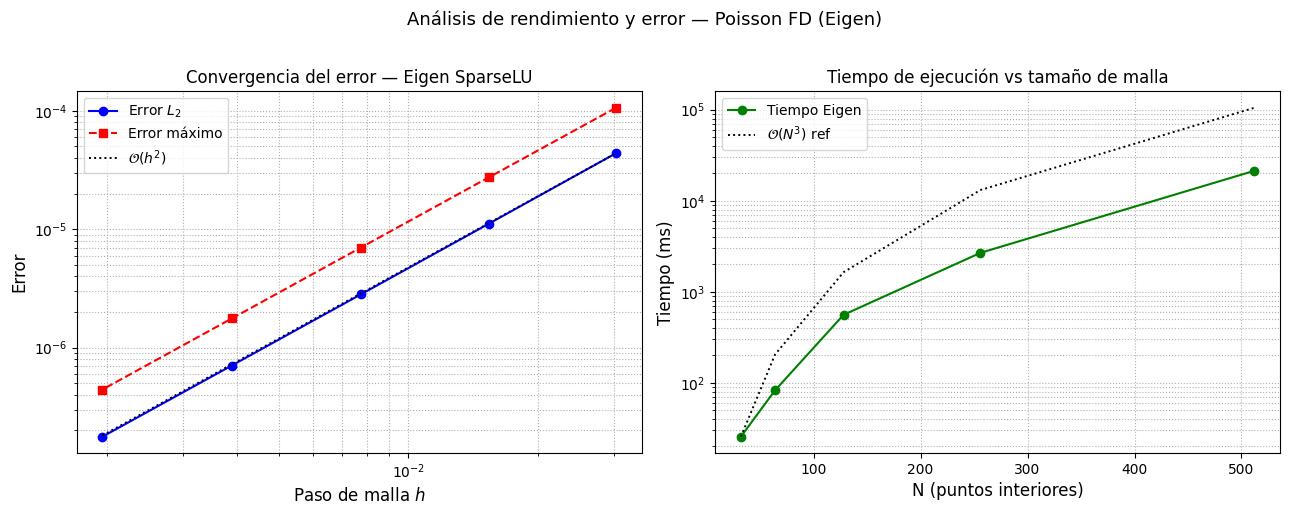

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df  = pd.read_csv("./metrics.csv")
h   = 1.0 / (df["N"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Error vs h (log-log) ─────────────────────────────────────────────────────
axes[0].loglog(h, df["errL2"],  "o-b", label="Error $L_2$")
axes[0].loglog(h, df["errMax"], "s--r", label="Error máximo")

# Referencia h²
h_arr  = h.values
scale  = df["errL2"].iloc[0] / h_arr[0]**2
h_ref  = np.linspace(h_arr.min(), h_arr.max(), 50)
axes[0].loglog(h_ref, scale * h_ref**2, "k:", lw=1.4, label="$\\mathcal{O}(h^2)$")

axes[0].set_xlabel("Paso de malla $h$", fontsize=12)
axes[0].set_ylabel("Error", fontsize=12)
axes[0].set_title("Convergencia del error — Eigen SparseLU", fontsize=12)
axes[0].legend(); axes[0].grid(True, which="both", ls=":")

# ── Tiempo vs N (semilogy) ───────────────────────────────────────────────────
axes[1].semilogy(df["N"], df["time_ms"], "o-g", label="Tiempo Eigen")

# Referencia O(N^3)
t0, N0 = df["time_ms"].iloc[0], df["N"].iloc[0]
N_arr  = df["N"].values
axes[1].semilogy(N_arr, t0 * (N_arr / N0)**3, "k:", lw=1.4, label="$\\mathcal{O}(N^3)$ ref")

axes[1].set_xlabel("N (puntos interiores)", fontsize=12)
axes[1].set_ylabel("Tiempo (ms)", fontsize=12)
axes[1].set_title("Tiempo de ejecución vs tamaño de malla", fontsize=12)
axes[1].legend(); axes[1].grid(True, which="both", ls=":")

plt.suptitle("Análisis de rendimiento y error — Poisson FD (Eigen)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("analisis_eigen.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Comparación de rendimiento

Se compara el tiempo de ejecución de **Eigen SparseLU** vs **Armadillo spsolve** en función del tamaño del sistema. También se incluye la escala de memoria estimada y el costo computacional esperado $\mathcal{O}(N^3)$ para solvers directos densos vs. $\mathcal{O}(N^2 \sqrt{N})$ para dispersos en 2D.


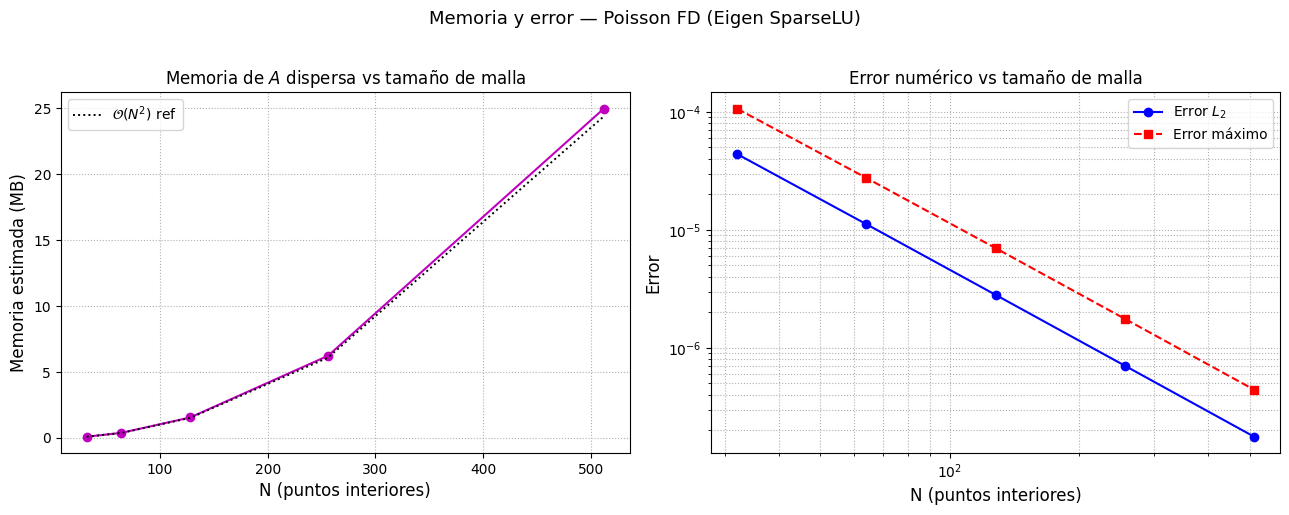

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("./metrics.csv")
h  = 1.0 / (df["N"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Memoria vs N ─────────────────────────────────────────────────────────────
axes[0].plot(df["N"], df["mem_MB"], "o-m")
# Referencia lineal en N^2
N_arr  = df["N"].values
m0, N0 = df["mem_MB"].iloc[0], N_arr[0]
axes[0].plot(N_arr, m0 * (N_arr / N0)**2, "k:", lw=1.4, label="$\\mathcal{O}(N^2)$ ref")
axes[0].set_xlabel("N (puntos interiores)", fontsize=12)
axes[0].set_ylabel("Memoria estimada (MB)", fontsize=12)
axes[0].set_title("Memoria de $A$ dispersa vs tamaño de malla", fontsize=12)
axes[0].legend(); axes[0].grid(True, ls=":")

# ── Error Máx vs h ───────────────────────────────────────────────────────────
axes[1].loglog(df["N"], df["errL2"],  "o-b", label="Error $L_2$")
axes[1].loglog(df["N"], df["errMax"], "s--r", label="Error máximo")
axes[1].set_xlabel("N (puntos interiores)", fontsize=12)
axes[1].set_ylabel("Error", fontsize=12)
axes[1].set_title("Error numérico vs tamaño de malla", fontsize=12)
axes[1].legend(); axes[1].grid(True, which="both", ls=":")

plt.suptitle("Memoria y error — Poisson FD (Eigen SparseLU)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("memoria_error_eigen.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Resultados gráficos

Visualización de la solución numérica, la solución analítica y el campo de error para la malla de mayor resolución disponible.


Visualizando: ./sol_512_eigen.csv  (N = 512)


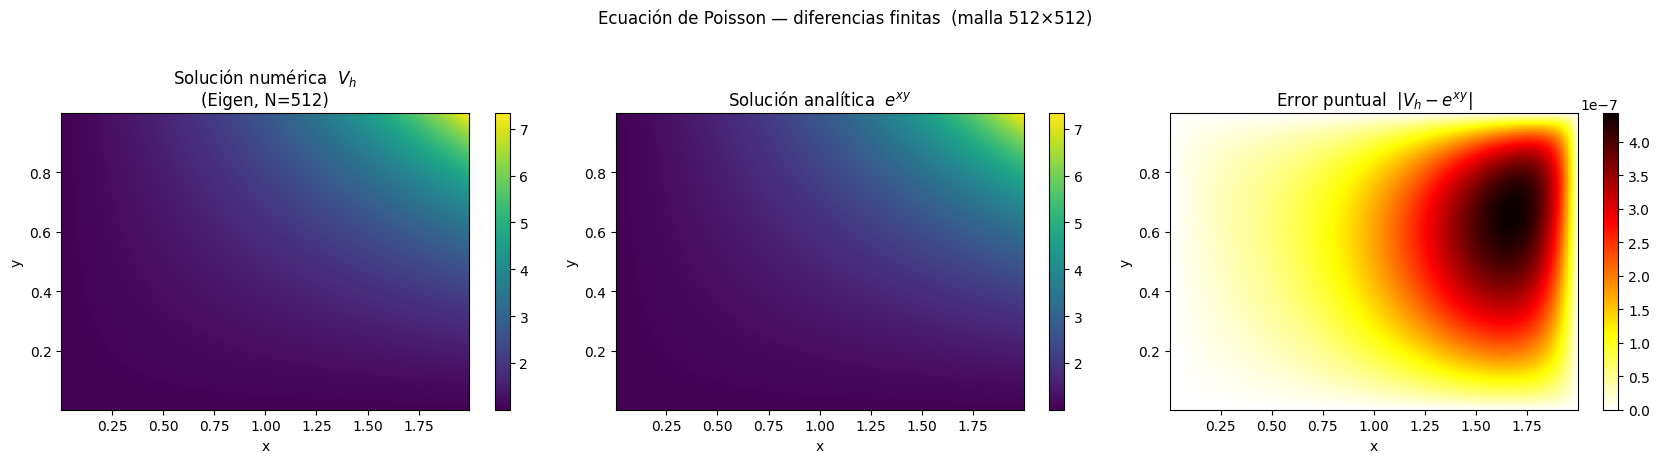

In [23]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Usar el CSV de mayor N disponible (solver eigen)
csv_files = sorted(glob.glob("./sol_*_eigen.csv"),
                   key=lambda f: int(f.split("_")[1]))

if not csv_files:
    print("No se encontraron archivos sol_*_eigen.csv")
    print("Ejecuta primero la celda de estudio de mallado.")
else:
    fname = csv_files[-1]   # mayor N
    N_used = int(fname.split("_")[1])
    print(f"Visualizando: {fname}  (N = {N_used})")

    sol = pd.read_csv(fname)
    x_vals = np.sort(sol["x"].unique())
    y_vals = np.sort(sol["y"].unique())
    X, Y   = np.meshgrid(x_vals, y_vals)

    pivot_num = sol.pivot_table(index="y", columns="x", values="V_num").values
    pivot_ex  = sol.pivot_table(index="y", columns="x", values="V_exact").values
    pivot_err = np.abs(pivot_num - pivot_ex)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    im0 = axes[0].pcolormesh(X, Y, pivot_num, shading="auto", cmap="viridis")
    axes[0].set_title(f"Solución numérica  $V_h$\n(Eigen, N={N_used})")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].pcolormesh(X, Y, pivot_ex,  shading="auto", cmap="viridis")
    axes[1].set_title("Solución analítica  $e^{xy}$")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].pcolormesh(X, Y, pivot_err, shading="auto", cmap="hot_r")
    axes[2].set_title("Error puntual  $|V_h - e^{xy}|$")
    plt.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x"); ax.set_ylabel("y")

    plt.suptitle(f"Ecuación de Poisson — diferencias finitas  (malla {N_used}×{N_used})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"solucion_N{N_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [24]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Detectar mallas disponibles ──────────────────────────────────────────────
csv_files = sorted(glob.glob("./sol_*_eigen.csv"),
                   key=lambda f: int(f.split("_")[1]))

if not csv_files:
    print("No hay archivos sol_*_eigen.csv. Ejecuta primero la celda de mallado.")
else:
    available_N = [int(f.split("_")[1]) for f in csv_files]

    # ── Widgets ──────────────────────────────────────────────────────────────
    dropdown = widgets.Dropdown(
        options=available_N,
        value=available_N[-1],
        description="Malla N:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="200px")
    )

    toggle_err = widgets.ToggleButton(
        value=True,
        description="Mostrar error",
        button_style="info",
        layout=widgets.Layout(width="140px")
    )

    cmap_sel = widgets.Dropdown(
        options=["viridis", "plasma", "inferno", "hot", "RdYlBu_r"],
        value="viridis",
        description="Colormap:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="200px")
    )

    out = widgets.Output()

    def plot_solucion(N_sel, show_err, cmap):
        fname = f"./sol_{N_sel}_eigen.csv"
        sol   = pd.read_csv(fname)
        x_vals = np.sort(sol["x"].unique())
        y_vals = np.sort(sol["y"].unique())
        X, Y   = np.meshgrid(x_vals, y_vals)

        pivot_num = sol.pivot_table(index="y", columns="x", values="V_num").values
        pivot_ex  = sol.pivot_table(index="y", columns="x", values="V_exact").values
        pivot_err = np.abs(pivot_num - pivot_ex)

        n_cols = 3 if show_err else 2
        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4.5))

        im0 = axes[0].pcolormesh(X, Y, pivot_num, shading="auto", cmap=cmap)
        axes[0].set_title(f"Solución numérica $V_h$\n(N = {N_sel})", fontsize=11)
        plt.colorbar(im0, ax=axes[0])

        im1 = axes[1].pcolormesh(X, Y, pivot_ex, shading="auto", cmap=cmap)
        axes[1].set_title("Solución analítica $e^{xy}$", fontsize=11)
        plt.colorbar(im1, ax=axes[1])

        if show_err:
            im2 = axes[2].pcolormesh(X, Y, pivot_err, shading="auto", cmap="hot_r")
            axes[2].set_title(f"Error puntual $|V_h - e^{{xy}}|$\nMáx = {pivot_err.max():.2e}", fontsize=11)
            plt.colorbar(im2, ax=axes[2])

        for ax in axes:
            ax.set_xlabel("x"); ax.set_ylabel("y")

        hx = 2.0 / (N_sel + 1)
        hy = 1.0 / (N_sel + 1)
        plt.suptitle(f"Poisson FD — malla {N_sel}×{N_sel}  "
                     f"($h_x$={hx:.4f}, $h_y$={hy:.4f})", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

    def on_change(_):
        with out:
            clear_output(wait=True)
            plot_solucion(dropdown.value, toggle_err.value, cmap_sel.value)

    dropdown.observe(on_change, names="value")
    toggle_err.observe(on_change, names="value")
    cmap_sel.observe(on_change, names="value")

    controls = widgets.HBox([dropdown, cmap_sel, toggle_err])
    display(controls, out)

    # Dibujar inicial
    with out:
        plot_solucion(dropdown.value, toggle_err.value, cmap_sel.value)


Output()